In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

### Load IRIS DataSet

In [ ]:
df = sb.load_dataset("iris")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


## Exploratory Data Analysis

In [ ]:
# Check if any rows has null values
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [ ]:
# Check what all unique species exists
df["species"].unique()
# This is the multi class classification problem

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [ ]:
# Check if data is balanced
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

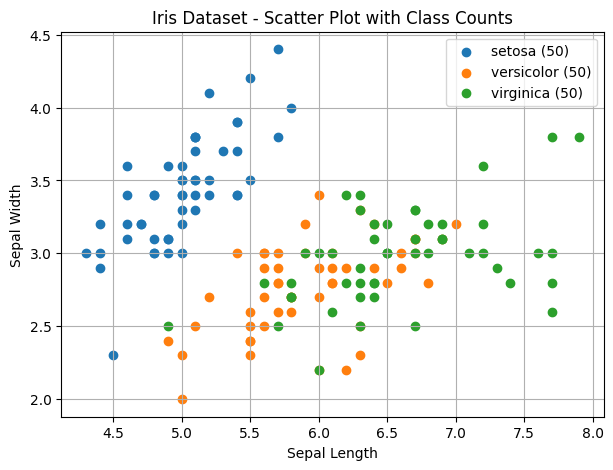

In [ ]:
# Get counts of all the class and plot in on the scatter graph: Sepal Data
counts = df["species"].value_counts()

plt.figure(figsize=(7,5))

for species in df["species"].unique():
    subset = df[df["species"] == species]
    plt.scatter(
        subset["sepal_length"],
        subset["sepal_width"],
        label=f"{species} ({counts[species]})"
    )
    # break

plt.title("Iris Dataset - Scatter Plot with Class Counts")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()
plt.grid(True)
plt.show()

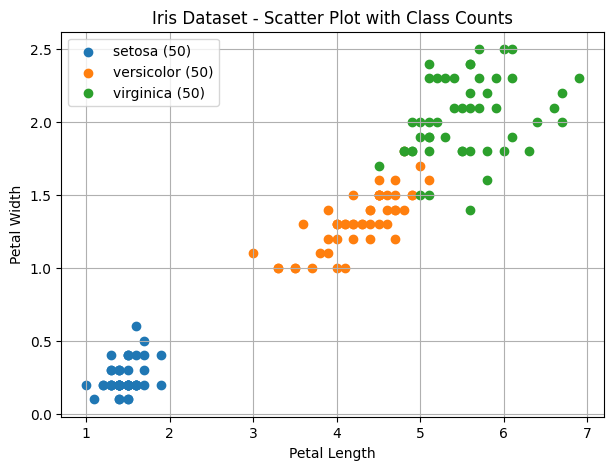

In [ ]:
# Get counts of all the class and plot in on the scatter graph: Petal Data
# Love the way how scatter plot shows the data based on different features🙂
counts = df["species"].value_counts()

plt.figure(figsize=(7,5))

for species in df["species"].unique():
    subset = df[df["species"] == species]
    plt.scatter(
        subset["petal_length"],
        subset["petal_width"],
        label=f"{species} ({counts[species]})"
    )

plt.title("Iris Dataset - Scatter Plot with Class Counts")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Numerical representation of species column
# Note: LabelEncoder or OHE can also be used for encoding the classes
df["species"] = df["species"].map({"setosa": 0, "versicolor": 1, "virginica": 2})
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# Split data into dependent and independent columns
X = df.drop("species", axis=1, index=None)
y = df["species"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=33, test_size=0.25)

## Model Training


In [ ]:
classifier = LogisticRegression()

parameters = {"penalty" : ["l1", "l2", "elasticnet"], 
               "C" : [1, 2, 4, 6, 10, 20, 30, 40, 50],
               "max_iter": [200, 400, 600]} #l2 penalty is a default choice.

In [ ]:
classfier_regressor = GridSearchCV(classifier, param_grid=parameters, scoring='accuracy', cv=5)
classfier_regressor.fit(X_train, y_train)
# 'scoring' parameter defines the strategy to evaluate the performance of the cross-validated model on the test set.
#  As the data is balanced 'accuracy' is used for the same.

e:\Projects\Logistic-Regression\.venv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
270 fits failed out of a total of 405.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
135 fits failed with the following error:
Traceback (most recent call last):
  File "e:\Projects\Logistic-Regression\.venv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "e:\Projects\Logistic-Regression\.venv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "e:\Projects\Logistic-Regression\.venv\lib\site-packages\sklearn\linear_model\_logistic.py", line 1218, in fit
    solve

,estimator,LogisticRegression()
,param_grid,"{'C': [1, 2, ...], 'max_iter': [200, 400, ...], 'penalty': ['l1', 'l2', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [ ]:
classfier_regressor.best_params_
# {'C': 100, 'max_iter': 400, 'penalty': 'l2'}

{'C': 4, 'max_iter': 200, 'penalty': 'l2'}

In [ ]:
y_pred = classfier_regressor.predict(X_test)
accuracy_score(y_test, y_pred)
# precision_score(y_test, y_pred, average="macro") 
# The default value for average is 'binary', but as this problem is about multi-class classification we need to explicity 
# pass the average parameter.
# Used average precision as 'macro' because the classes are equally distributed, and no imbalance exists in the data.

0.9736842105263158